In [1]:
# !pip install torch
# !pip install torchviz

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

import numpy as np

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import time

np.random.seed(42)
tf.random.set_seed(42)

Device: cpu


# load a scikit-learn regression dataset (NumPy)

In [3]:


# Load data 
X, y = load_diabetes(return_X_y=True)   # X: (442, 10), y: (442,)
print("X shape:", X.shape, "y shape:", y.shape)

# Train/test split
X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X, y, test_size=0.2, random_state=5
)

# Standardize features 
scaler = StandardScaler()
X_train_np = scaler.fit_transform(X_train_np)
X_test_np = scaler.transform(X_test_np)

print(X_train_np.shape, y_train_np.shape)

X shape: (442, 10) y shape: (442,)
(353, 10) (353,)


## Build and train tensorflow model

In [4]:
keras_model = keras.Sequential([
    layers.Input(shape=(X_train_np.shape[1],)),
    layers.Dense(150, activation="relu"),
    layers.Dense(150, activation="relu"),
    layers.Dense(1)  # regression output
])

keras_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mae"
)
start_time = time.time()
result = keras_model.fit(
    x=X_train_np, y=y_train_np,
    validation_data=(X_test_np,y_test_np),
    epochs=350,
    batch_size=16,
    verbose=1
)
end_time = time.time()
y_train_np_hat=keras_model.predict(X_train_np)
y_test_np_hat=keras_model.predict(X_test_np)

print("Final val MAE:", result.history["val_loss"][-1])

Epoch 1/350
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 148.2876 - val_loss: 151.6139
Epoch 2/350
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 139.7122 - val_loss: 136.8565
Epoch 3/350
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 119.5660 - val_loss: 105.3764
Epoch 4/350
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 84.5358 - val_loss: 63.8340
Epoch 5/350
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 59.3237 - val_loss: 58.4636
Epoch 6/350
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 53.9410 - val_loss: 53.6440
Epoch 7/350
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 50.9267 - val_loss: 50.4820
Epoch 8/350
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 49.2840 - val_loss: 48.5896
Epoch 9/350
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 47.5818 - val_loss: 47.5225
Epoch 10/350
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 46.4401 - val_loss: 46.7781
Epoch 11/350
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 45.5399 - val_loss: 46.2165
Epoch 12/350
23/23 ━━━━━━━━━━━━━━

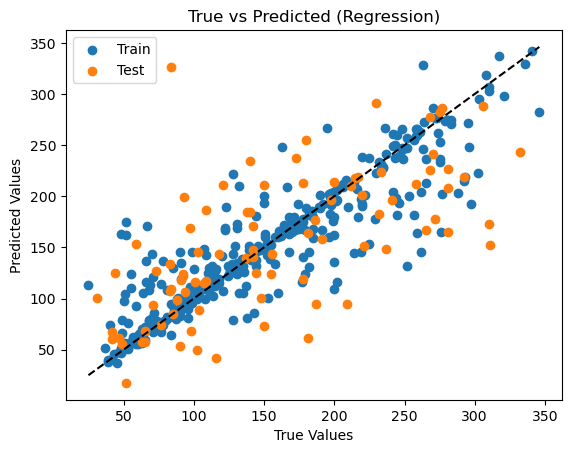

Keras Results
Train MAE: 20.0086
Train R2 : 0.8124

Test MAE : 45.5943
Test R2  : 0.3957


In [5]:
import matplotlib.pyplot as plt

# Perfect prediction line
min_val = min(y_test_np.min(), y_train_np.min())
max_val = max(y_test_np.max(), y_train_np.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--')

plt.scatter(y_train_np, y_train_np_hat, label="Train")
plt.scatter(y_test_np, y_test_np_hat, label="Test")
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("True vs Predicted (Regression)")
plt.legend()
plt.show()

mae_train = mean_absolute_error(y_train_np, y_train_np_hat)
r2_train  = r2_score(y_train_np, y_train_np_hat)

mae_test = mean_absolute_error(y_test_np, y_test_np_hat)
r2_test  = r2_score(y_test_np, y_test_np_hat)

print("Keras Results")
print(f"Train MAE: {mae_train:.4f}")
print(f"Train R2 : {r2_train:.4f}")
print()
print(f"Test MAE : {mae_test:.4f}")
print(f"Test R2  : {r2_test:.4f}")

## Build and train pytorch model

In [6]:
# Convert to tensors
X_train_pt = torch.tensor(X_train_np, dtype=torch.float32)
y_train_pt = torch.tensor(y_train_np, dtype=torch.float32).view(-1, 1)

X_test_pt  = torch.tensor(X_test_np, dtype=torch.float32)
y_test_pt  = torch.tensor(y_test_np, dtype=torch.float32).view(-1, 1)

In [7]:
train_ds = TensorDataset(X_train_pt, y_train_pt)
test_ds  = TensorDataset(X_test_pt, y_test_pt)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=256, shuffle=False)

In [8]:
train_ds[0]

(tensor([ 1.6690,  1.1109, -0.5045, -0.7356, -1.4742, -0.9592, -0.8566, -0.0076,
         -0.8352, -0.0715]),
 tensor([199.]))

In [9]:
for xb, yb in train_loader:
    print("Batch X shape:", xb.shape)
    print("Batch y shape:", yb.shape)
    print(xb[:2])   # first 2 samples in batch
    print(yb[:2])
    break

Batch X shape: torch.Size([16, 10])
Batch y shape: torch.Size([16, 1])
tensor([[ 1.6690,  1.1109, -0.5045, -0.7356, -1.4742, -0.9592, -0.8566, -0.0076,
         -0.8352, -0.0715],
        [ 0.7570,  1.1109,  1.3008,  0.4744, -0.9104, -0.7075, -0.9336, -0.0076,
          0.4527, -0.3370]])
tensor([[199.],
        [151.]])


In [10]:
len(train_loader)

23

In [11]:
torch_model = nn.Sequential(
    nn.Linear(X_train_pt.shape[1], 150),
    nn.ReLU(),
    nn.Linear(150, 150),
    nn.ReLU(),
    nn.Linear(150, 1)
).to(device)

criterion = nn.L1Loss()
optimizer = torch.optim.Adam(torch_model.parameters(), lr=1e-3)

In [12]:
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

@torch.no_grad()
def predict(model, loader):
    model.eval()
    
    preds = []
    targets = []
    
    for xb, yb in loader:
        xb = xb.to(device)
        
        pred = model(xb)
        
        preds.append(pred.cpu())
        targets.append(yb)
    
    preds = torch.cat(preds).numpy().squeeze()
    targets = torch.cat(targets).numpy().squeeze()
    
    return preds, targets

In [13]:
start_timePT = time.time()
epochs = 350
for epoch in range(1, epochs + 1):
    loss = train_one_epoch(torch_model, train_loader)

    if epoch % 20 == 0:
        print(f"Epoch {epoch:03d} | train loss (MAE): {loss:.4f}")

end_timePT = time.time()

Epoch 020 | train loss (MAE): 40.2497
Epoch 040 | train loss (MAE): 37.7836
Epoch 060 | train loss (MAE): 36.4912
Epoch 080 | train loss (MAE): 35.5443
Epoch 100 | train loss (MAE): 34.2370
Epoch 120 | train loss (MAE): 33.2510
Epoch 140 | train loss (MAE): 32.2185
Epoch 160 | train loss (MAE): 31.3849
Epoch 180 | train loss (MAE): 30.3677
Epoch 200 | train loss (MAE): 29.4117
Epoch 220 | train loss (MAE): 28.8308
Epoch 240 | train loss (MAE): 28.0109
Epoch 260 | train loss (MAE): 26.9980
Epoch 280 | train loss (MAE): 26.3496
Epoch 300 | train loss (MAE): 25.6414
Epoch 320 | train loss (MAE): 24.4863
Epoch 340 | train loss (MAE): 23.9570


In [14]:
y_pred_train, y_true_train = predict(torch_model, train_loader)
y_pred_test,  y_true_test  = predict(torch_model, test_loader)

# Metrics train
mae_trainPT = mean_absolute_error(y_true_train, y_pred_train)
r2_trainPT  = r2_score(y_true_train, y_pred_train)

# Metrics test
mae_testPT = mean_absolute_error(y_true_test, y_pred_test)
r2_testPT  = r2_score(y_true_test, y_pred_test)

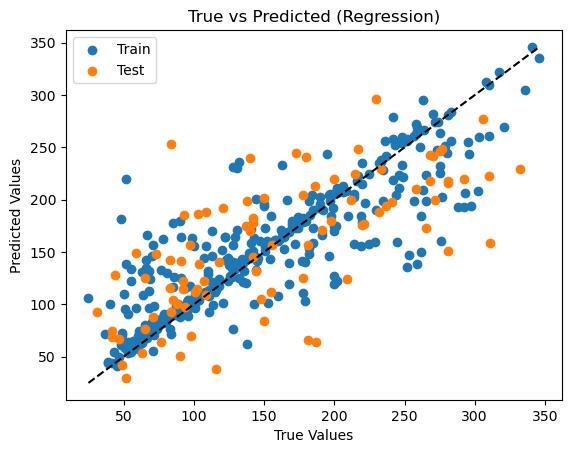


PyTorch Results (Train)
MAE: 24.5414
R2 : 0.7502

PyTorch Results (Test)
MAE: 46.6927
R2 : 0.4645


In [15]:
import matplotlib.pyplot as plt

# Perfect prediction line
min_val = min(y_test_pt.min(), y_train_pt.min())
max_val = max(y_test_pt.max(), y_train_pt.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--')

plt.scatter(y_true_train, y_pred_train, label="Train")
plt.scatter(y_true_test, y_pred_test, label="Test")
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("True vs Predicted (Regression)")
plt.legend()
plt.show()

print("\nPyTorch Results (Train)")
print(f"MAE: {mae_trainPT:.4f}")
print(f"R2 : {r2_trainPT:.4f}")

print("\nPyTorch Results (Test)")
print(f"MAE: {mae_testPT:.4f}")
print(f"R2 : {r2_testPT:.4f}")

In [16]:
!pip install torchinfo

import torchinfo
from torchinfo import summary

summary(torch_model, input_size=(1, X_train_pt.shape[1]))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 1]                    --
├─Linear: 1-1                            [1, 150]                  1,650
├─ReLU: 1-2                              [1, 150]                  --
├─Linear: 1-3                            [1, 150]                  22,650
├─ReLU: 1-4                              [1, 150]                  --
├─Linear: 1-5                            [1, 1]                    151
Total params: 24,451
Trainable params: 24,451
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.02
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.10
Estimated Total Size (MB): 0.10

In [17]:
keras_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 150)                 │           1,650 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 150)                 │          22,650 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │             151 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 73,355 (286.55 KB)

 Trainable params: 24,451 (95.51 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 48,904 (191.04 KB)

In [18]:
print(f"Keras/Tensorflow training time: {end_time - start_time:.2f} seconds")
print(f"PyTorch training time: {end_timePT - start_timePT:.2f} seconds")

Keras/Tensorflow training time: 112.46 seconds
PyTorch training time: 19.90 seconds
